# Property Price Forecasting
### Australian Residential Sales | Time Series

Forecast monthly median residential sale price, so that agents and lenders
can anticipate market movement rather than react to it.

**Dataset:** raw_sales.csv — 29,580 individual sales, Feb 2007 – Jul 2019 | 5 columns
**Target:** monthly median sale price (constructed) | **Approach:** CRISP-DM

## 0. Business Understanding

### Background
Residential property is illiquid and slow-moving, so decisions made today
are exposed to market conditions twelve months out. Agents set commission
forecasts, lenders set loan-to-value limits, and developers commit capital
against an expectation of where prices will be.

### Business Problem
Anticipate the direction and level of the local market twelve months
ahead. This supports:

- Revenue forecasting for agencies
- Risk assessment on new lending
- Timing of development and release decisions

### ML Objective
Build a **time series forecasting model** that predicts monthly median
sale price twelve months ahead, using only price history available at the
point of forecast.

### Success Criteria
- **Primary metric:** RMSE in dollars on a temporally held-out period
- **Secondary:** MAPE, which is comparable across price levels, and R²
- **Baselines to beat:** naive (next = current) and seasonal naive
  (next March = last March). On property data these are difficult
  benchmarks, and a model that fails to beat them adds nothing.

### Model Validation Checks
- `TimeSeriesSplit` throughout — standard K-fold would train on later data
  to predict earlier data
- Test period held out by date, evaluated once
- Residuals checked for remaining autocorrelation

# Data Loading

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

raw = pd.read_csv("raw_sales.csv")
raw["datesold"] = pd.to_datetime(raw["datesold"])

print(raw.shape)
raw.head()

(29580, 5)


,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07,2607,525000,house,4
1,2007-02-27,2906,290000,house,3
2,2007-03-07,2905,328000,house,3
3,2007-03-09,2905,380000,house,4
4,2007-03-21,2906,310000,house,3


In [2]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datesold      29580 non-null  datetime64[ns]
 1   postcode      29580 non-null  int64         
 2   price         29580 non-null  int64         
 3   propertyType  29580 non-null  object        
 4   bedrooms      29580 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


In [3]:
raw.describe()

,datesold,postcode,price,bedrooms
count,29580,29580.000000,2.958000e+04,29580.000000
mean,2015-02-21 07:35:42.474645248,2730.249730,6.097363e+05,3.250169
min,2007-02-07 00:00:00,2600.000000,5.650000e+04,0.000000
25%,2013-02-05 00:00:00,2607.000000,4.400000e+05,3.000000
50%,2015-09-30 00:00:00,2615.000000,5.500000e+05,3.000000
75%,2017-07-26 00:00:00,2905.000000,7.050000e+05,4.000000
max,2019-07-27 00:00:00,2914.000000,8.000000e+06,5.000000
std,NaN,146.717292,2.817079e+05,0.951275


In [4]:
raw.isnull().sum()

datesold        0
postcode        0
price           0
propertyType    0
bedrooms        0
dtype: int64

In [5]:
print("date range:", raw["datesold"].min().date(), "to", raw["datesold"].max().date())
print("span:", round((raw["datesold"].max() - raw["datesold"].min()).days / 365.25, 1), "years")
print("postcodes:", raw["postcode"].nunique())
print("property types:", raw["propertyType"].unique())
print("bedrooms:", sorted(raw["bedrooms"].unique()))

date range: 2007-02-07 to 2019-07-27
span: 12.5 years
postcodes: 27
property types: ['house' 'unit']
bedrooms: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [6]:
print(raw.set_index("datesold").resample("YE").size().to_string())

datesold
2007-12-31     147
2008-12-31     639
2009-12-31    1426
2010-12-31    1555
2011-12-31    1633
2012-12-31    1858
2013-12-31    2119
2014-12-31    2863
2015-12-31    3648
2016-12-31    3908
2017-12-31    4541
2018-12-31    3858
2019-12-31    1385
Freq: YE-DEC


In [7]:
print("bedrooms = 0:", (raw["bedrooms"] == 0).sum())
raw["bedrooms"].value_counts().sort_index()

bedrooms = 0: 30


bedrooms
0       30
1     1627
2     3598
3    11933
4    10442
5     1950
Name: count, dtype: int64

In [8]:
raw["propertyType"].value_counts()

propertyType
house    24552
unit      5028
Name: count, dtype: int64

In [9]:
raw.groupby("propertyType")["price"].median()

propertyType
house    585000.0
unit     390000.0
Name: price, dtype: float64

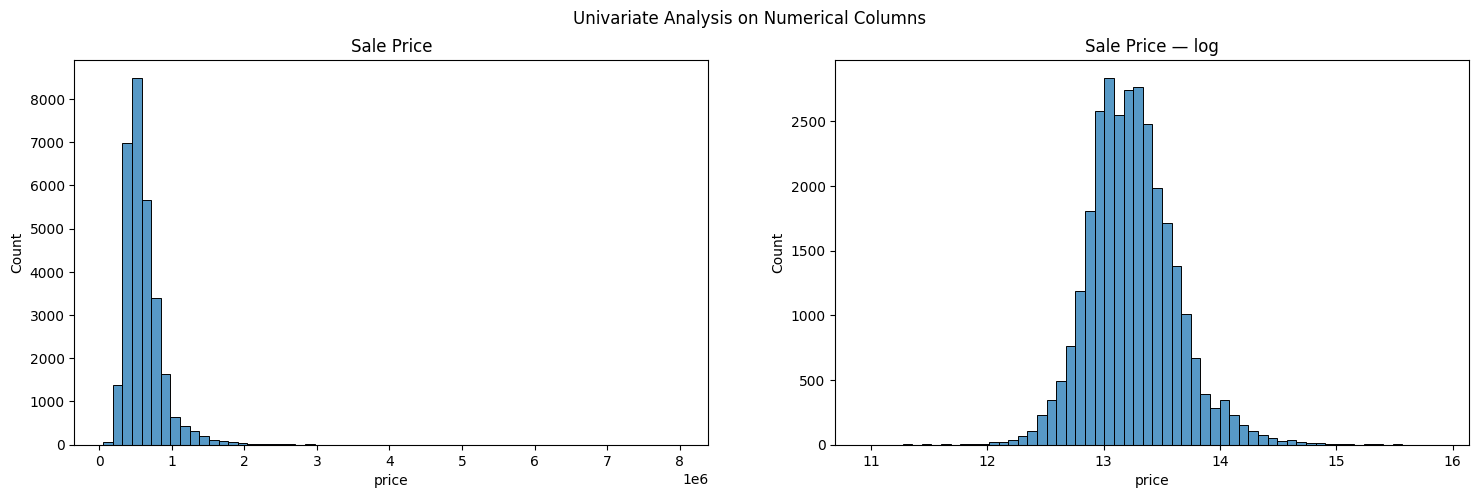

In [10]:
plt.rcParams["figure.figsize"] = (18, 5)
plt.subplot(1, 2, 1); sns.histplot(raw["price"], bins=60); plt.title("Sale Price")
plt.subplot(1, 2, 2); sns.histplot(np.log1p(raw["price"]), bins=60); plt.title("Sale Price — log")
plt.suptitle("Univariate Analysis on Numerical Columns")
plt.show()

In [11]:
print("skew:", round(raw["price"].skew(), 2))

skew: 4.31


In [12]:
# Drop the 30 rows with bedrooms = 0 (undocumented, not a valid category)
clean = raw[raw["bedrooms"] > 0].copy()

# Houses only — units are a distinct market (median $390k vs $585k),
# so a shifting sales mix would move the series without any price change
clean = clean[clean["propertyType"] == "house"]

print(f"{len(raw):,} -> {len(clean):,} rows")

29,580 -> 24,533 rows


In [13]:
monthly = clean.set_index("datesold")["price"].resample("ME").agg(["median", "size"])
monthly.columns = ["median_price", "n_sales"]

# Series starts 2009: 2007 has only 147 sales for the year (~12/month),
# too few for a stable monthly median
monthly = monthly["2009-01":]

print(monthly.shape)
print("min sales in a month:", monthly["n_sales"].min())
monthly.head()

(127, 2)
min sales in a month: 44


,median_price,n_sales
datesold,,
2009-01-31,450000.0,76
2009-02-28,450000.0,91
2009-03-31,460000.0,147
2009-04-30,462250.0,104
2009-05-31,458500.0,114


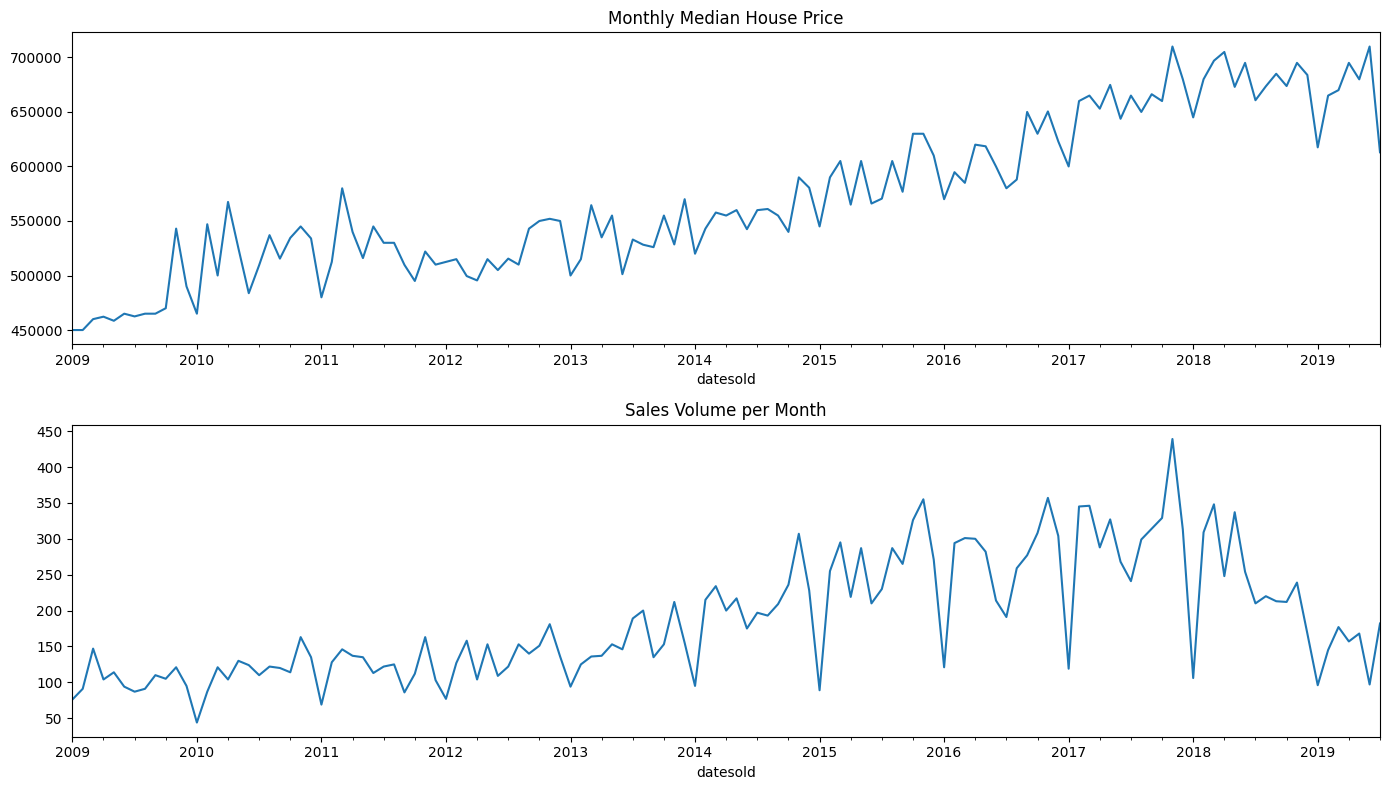

In [14]:
plt.rcParams["figure.figsize"] = (14, 8)
plt.subplot(2, 1, 1)
monthly["median_price"].plot(title="Monthly Median House Price")
plt.subplot(2, 1, 2)
monthly["n_sales"].plot(title="Sales Volume per Month")
plt.tight_layout(); plt.show()

# Time Series Analysis

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

y = monthly["median_price"]

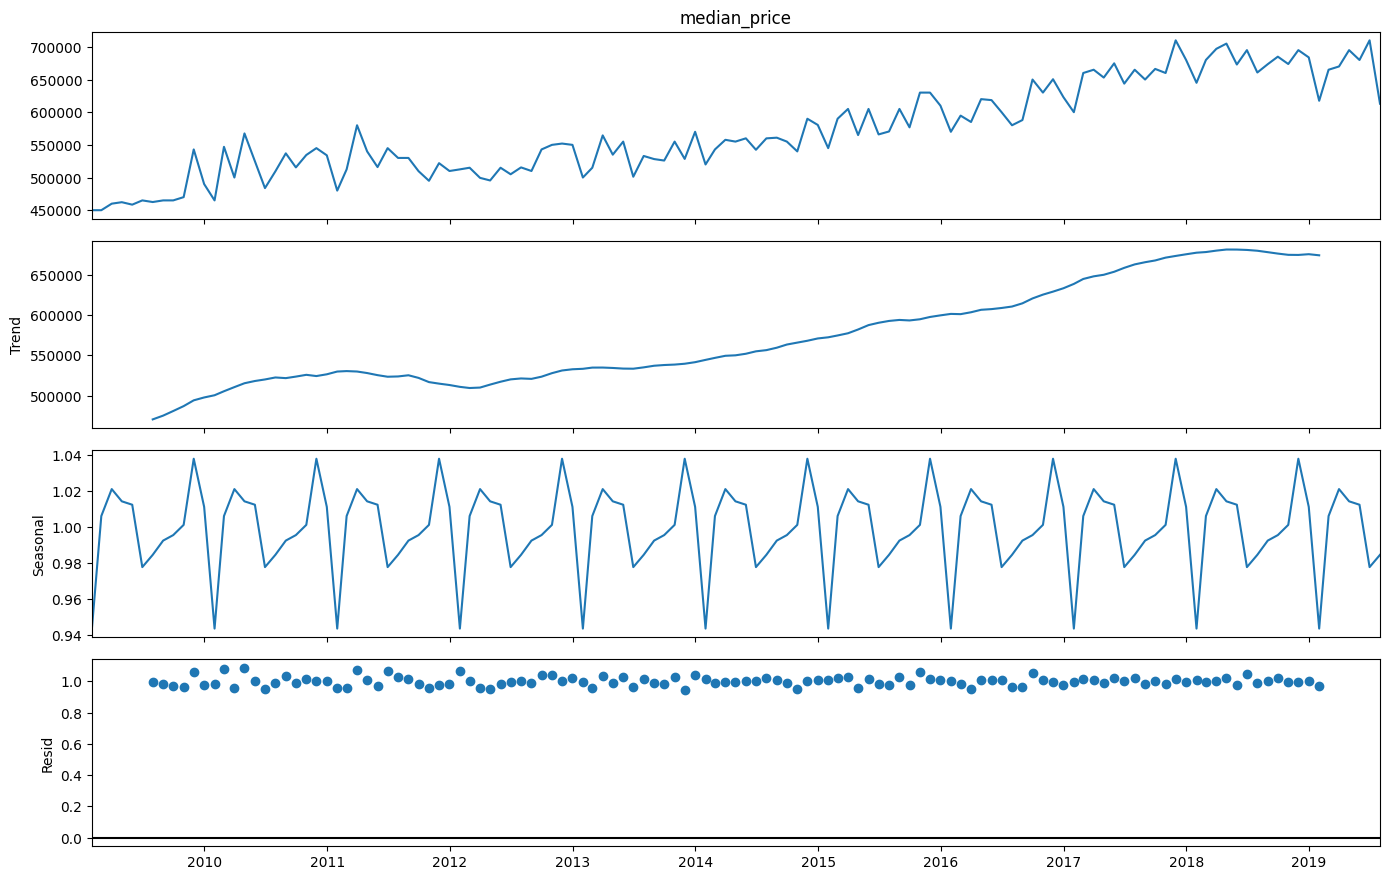

In [16]:
# Decomposition — separates trend, seasonality and residual
decomp = seasonal_decompose(y, model="multiplicative", period=12)
decomp.plot()
plt.gcf().set_size_inches(14, 9)
plt.show()

In [17]:
# Stationarity — ADF test. p < 0.05 means stationary.
def adf(series, name):
    r = adfuller(series.dropna())
    print(f"{name:22s} ADF {r[0]:>7.3f}  p={r[1]:.4f}  {'stationary' if r[1]<0.05 else 'NON-stationary'}")

adf(y, "original")
adf(y.diff(), "1st difference")
adf(y.diff().diff(12), "1st + seasonal diff")

original               ADF  -0.957  p=0.7687  NON-stationary
1st difference         ADF  -9.312  p=0.0000  stationary
1st + seasonal diff    ADF  -3.606  p=0.0056  stationary


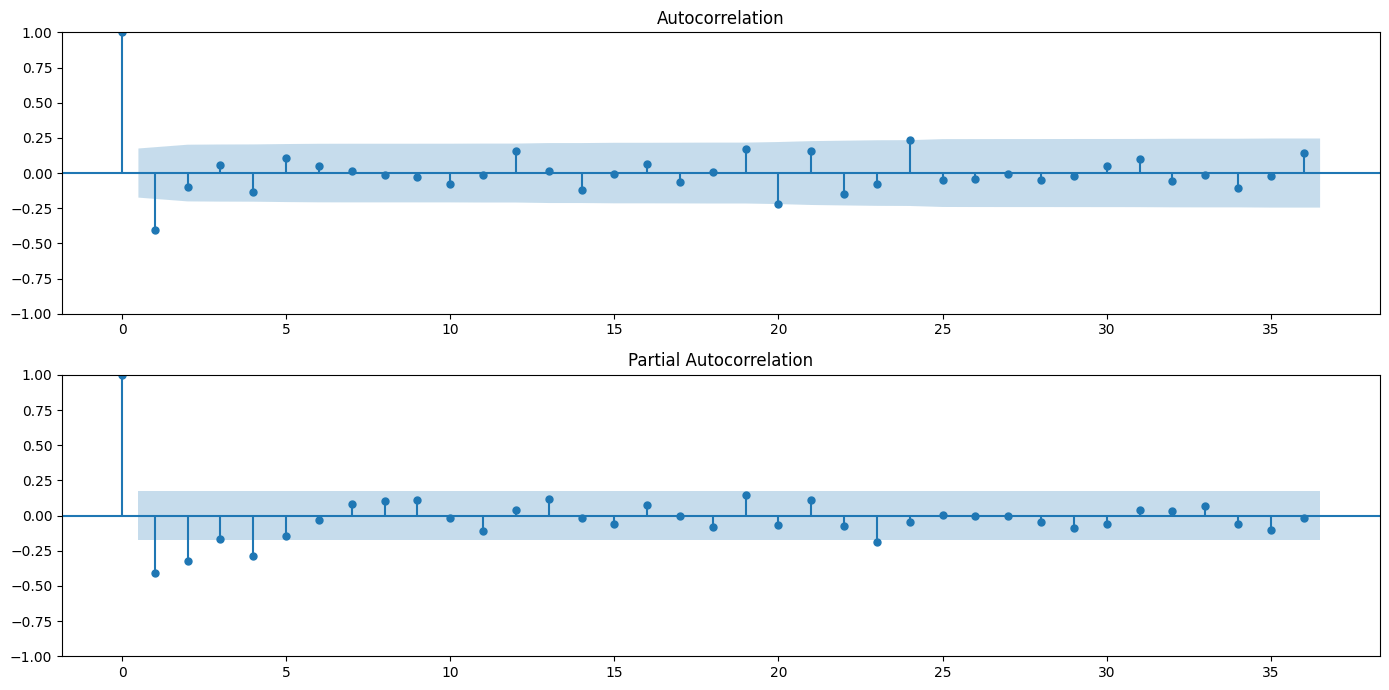

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(y.diff().dropna(), lags=36, ax=ax[0])
plot_pacf(y.diff().dropna(), lags=36, ax=ax[1])
plt.tight_layout(); plt.show()

### Stationarity and seasonality

| Series | ADF statistic | p-value | Result |
|---|---|---|---|
| Original | −0.957 | 0.7687 | Non-stationary |
| 1st difference | −9.312 | <0.0001 | Stationary |
| 1st + seasonal difference | −3.606 | 0.0056 | Stationary, over-differenced |

First differencing is sufficient (**d = 1**). Adding a seasonal difference
weakens the test statistic, indicating over-differencing, so **D = 0** is
the starting point.

Multiplicative decomposition shows a highly regular annual seasonal
component ranging 0.94–1.04 — a ±5% swing repeating consistently across
ten cycles. The trend shows three regimes: a plateau from 2010 to 2013,
acceleration from 2014 to 2018, and a flattening thereafter. Residuals are
centred on 1.0 with no visible structure.

On the differenced series, ACF cuts off after a single negative spike at
lag 1 (≈ −0.42) while PACF decays gradually — the signature of an MA(1)
process, giving **q = 1, p = 0**. A modest ACF spike near lag 24 suggests
residual seasonal structure, so **Q = 1** is included in the grid.

Starting specification: **SARIMA(0,1,1)(0,1,1,12)**.

# Train/Test Split

In [19]:
train = monthly["median_price"][:"2017-12"]
test = monthly["median_price"]["2018-01":]

print(f"train: {train.index.min().date()} to {train.index.max().date()}  ({len(train)} months)")
print(f"test:  {test.index.min().date()} to {test.index.max().date()}  ({len(test)} months)")

train: 2009-01-31 to 2017-12-31  (108 months)
test:  2018-01-31 to 2019-07-31  (19 months)


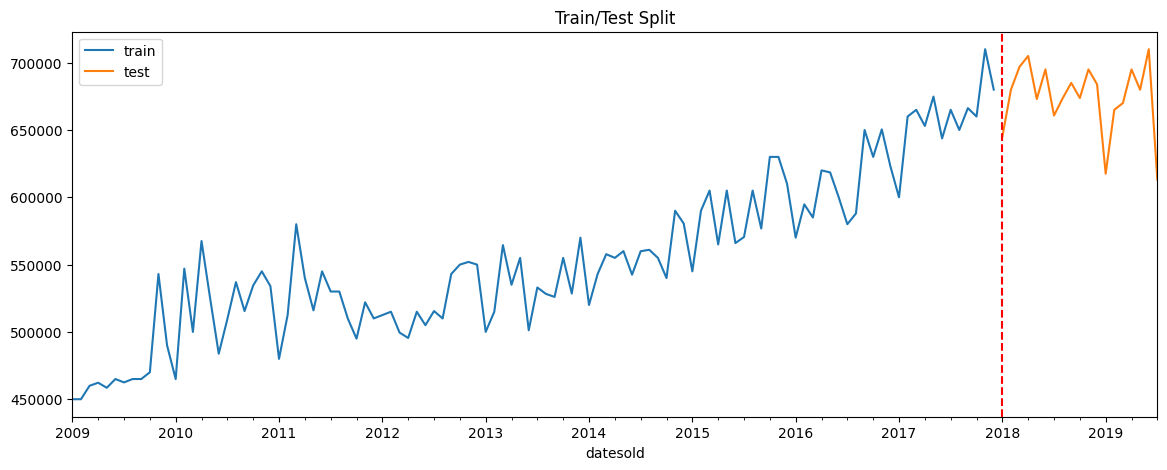

In [20]:
plt.rcParams["figure.figsize"] = (14, 5)
train.plot(label="train")
test.plot(label="test")
plt.axvline(pd.Timestamp("2018-01-01"), color="red", linestyle="--")
plt.title("Train/Test Split")
plt.legend(); plt.show()

**Split by date, not at random.** Training covers Jan 2009 – Dec 2017
(108 months); testing covers Jan 2018 – Jul 2019 (19 months). A random
split would train on 2019 to predict 2012.

The test period contains a turning point — the series peaks in early 2018
and declines through 2019 — so the models are tested on a trend reversal
rather than a smooth continuation. This is the harder case and the more
informative one.

## 6. Modelling
Training and comparing 7 forecasting models.
Evaluation metric: RMSE in dollars, with MAPE and R² alongside.

**Note on cross-validation:** standard K-fold is invalid for time series —
it would train on later data to predict earlier data. `TimeSeriesSplit`
is used for the supervised models, and rolling-origin evaluation for the
statistical ones.

## 6. Modelling
Training and comparing forecasting models across four families: baselines,
exponential smoothing, the ARIMA family, and lag-feature machine learning.
Evaluation metric: RMSE in dollars, with MAPE and R² alongside.

**Note on validation:** standard K-fold cross-validation is invalid here —
it would train on later data to predict earlier data. `TimeSeriesSplit` is
used for the supervised models. Deep learning (LSTM, N-BEATS) was ruled
out: 127 monthly observations is far too few.

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = []

def evaluate(pred, name):
    pred = pd.Series(np.asarray(pred, dtype=float), index=test.index)
    rmse = np.sqrt(mean_squared_error(test, pred))
    mae = mean_absolute_error(test, pred)
    mape = (abs(test - pred) / test).mean() * 100
    r2 = r2_score(test, pred)
    results.append({"model": name, "RMSE": round(rmse), "MAE": round(mae),
                    "MAPE": round(mape, 2), "R2": round(r2, 4)})
    print(f"{name:28s} RMSE ${rmse:>8,.0f}  MAE ${mae:>7,.0f}  MAPE {mape:>5.2f}%  R² {r2:>7.4f}")
    return pred

# 6.1 Naive Forecast

### 6.1 Naive Forecast
Every future month equals the last observed value. No parameters, no
fitting. Every model below must beat this to justify its complexity.

In [22]:
naive_pred = np.repeat(train.iloc[-1], len(test))
p_naive = evaluate(naive_pred, "Naive")

Naive                        RMSE $  26,133  MAE $ 18,658  MAPE  2.85%  R² -0.0447


### 6.2 Seasonal Naive
Each month equals the same month one year earlier, capturing the ±5%
annual seasonality identified in section 5 with no model at all.

In [23]:
seasonal_pred = [train.iloc[-12 + (i % 12)] for i in range(len(test))]
p_snaive = evaluate(seasonal_pred, "Seasonal Naive")

Seasonal Naive               RMSE $  31,932  MAE $ 24,950  MAPE  3.69%  R² -0.5598


### 6.3 Drift Method
Extends the average historical growth rate forward. Given the strong
upward trend, this is the most demanding of the three baselines — and the
one most exposed to the trend reversal in the test period.

In [24]:
slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
drift_pred = train.iloc[-1] + slope * np.arange(1, len(test) + 1)
p_drift = evaluate(drift_pred, "Drift")

Drift                        RMSE $  40,254  MAE $ 29,959  MAPE  4.59%  R² -1.4788


R² is reported for completeness but is misleading here. It compares against
the mean of the *test* period, which a forecaster could not know in
advance. Across a nearly flat test window that mean is a strong benchmark,
so negative values are expected even for reasonable forecasts. RMSE and
MAPE are the meaningful metrics.

### 6.4 Holt-Winters Exponential Smoothing
Models level, trend and seasonality with exponentially decaying weights.
Damped trend is included in the comparison because the undamped version
will extrapolate the pre-2018 growth into a period that flattens.

In [25]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw = ExponentialSmoothing(train, trend="add", seasonal="mul",
                          seasonal_periods=12).fit()
p_hw = evaluate(hw.forecast(len(test)), "Holt-Winters")

hw_d = ExponentialSmoothing(train, trend="add", damped_trend=True,
                            seasonal="mul", seasonal_periods=12).fit()
p_hwd = evaluate(hw_d.forecast(len(test)), "Holt-Winters (damped)")

Holt-Winters                 RMSE $  48,271  MAE $ 38,065  MAPE  5.76%  R² -2.5644
Holt-Winters (damped)        RMSE $  33,344  MAE $ 26,147  MAPE  3.96%  R² -0.7008


### 6.5 ARIMA
Non-seasonal ARIMA(0,1,1), from the ACF/PACF analysis in section 5.
Included as a comparison against SARIMA, to quantify what the seasonal
component actually contributes.

In [26]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(train, order=(0, 1, 1)).fit()
p_arima = evaluate(arima.forecast(len(test)), "ARIMA(0,1,1)")

ARIMA(0,1,1)                 RMSE $  27,068  MAE $ 19,208  MAPE  2.94%  R² -0.1208


In [27]:
print(arima.summary())

                               SARIMAX Results                                
Dep. Variable:           median_price   No. Observations:                  108
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -1253.550
Date:                Wed, 09 Sep 2026   AIC                           2511.101
Time:                        12:42:29   BIC                           2516.446
Sample:                    01-31-2009   HQIC                          2513.268
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1563      0.023     -6.902      0.000      -0.201      -0.112
sigma2      6.751e+08   1.65e-12   4.09e+20      0.000    6.75e+08    6.75e+08
Ljung-Box (L1) (Q):                  11.42   Jarque-

### 6.6 SARIMA
Adds the seasonal component: SARIMA(0,1,1)(0,1,1,12).

In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(train, order=(0,1,1), seasonal_order=(0,1,1,12)).fit(disp=False)
p_sarima = evaluate(sarima.forecast(len(test)), "SARIMA(0,1,1)(0,1,1,12)")

SARIMA(0,1,1)(0,1,1,12)      RMSE $  52,953  MAE $ 42,411  MAPE  6.41%  R² -3.2895


In [29]:
# D=0 — the ADF test said the seasonal difference over-differences
sarima2 = SARIMAX(train, order=(0,1,1), seasonal_order=(0,0,1,12)).fit(disp=False)
p_sarima2 = evaluate(sarima2.forecast(len(test)), "SARIMA(0,1,1)(0,0,1,12)")

SARIMA(0,1,1)(0,0,1,12)      RMSE $  27,231  MAE $ 19,279  MAPE  2.95%  R² -0.1344


In [30]:
# Ljung-Box said residual autocorrelation remains — try more MA terms
for order in [(0,1,2), (1,1,1), (2,1,2), (1,1,0)]:
    m = ARIMA(train, order=order).fit()
    evaluate(m.forecast(len(test)), f"ARIMA{order}")

ARIMA(0, 1, 2)               RMSE $  26,725  MAE $ 19,023  MAPE  2.91%  R² -0.0926
ARIMA(1, 1, 1)               RMSE $  26,765  MAE $ 19,045  MAPE  2.91%  R² -0.0958
ARIMA(2, 1, 2)               RMSE $  25,707  MAE $ 18,492  MAPE  2.82%  R² -0.0110
ARIMA(1, 1, 0)               RMSE $  27,160  MAE $ 19,256  MAPE  2.95%  R² -0.1284


In [31]:
import itertools
rows = []
for p, q in itertools.product(range(4), range(4)):
    try:
        m = ARIMA(train, order=(p,1,q)).fit()
        pred = m.forecast(len(test))
        rows.append({"order": f"({p},1,{q})",
                     "rmse": round(np.sqrt(mean_squared_error(test, pred))),
                     "aic": round(m.aic, 1)})
    except Exception:
        pass
pd.DataFrame(rows).sort_values("rmse").head(10)

C:\Users\zainh\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\zainh\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,rmse,aic
6,"(1,1,2)",25696,2512.4
7,"(1,1,3)",25702,2516.5
10,"(2,1,2)",25707,2514.5
13,"(3,1,1)",25751,2513.9
9,"(2,1,1)",25774,2512.1
0,"(0,1,0)",26133,2513.1
2,"(0,1,2)",26725,2512.9
5,"(1,1,1)",26765,2512.8
8,"(2,1,0)",26817,2513.1
3,"(0,1,3)",26818,2517.6


### ARIMA order selection

A grid over p, q ∈ {0,1,2,3} with d=1 was evaluated. Five specifications
cluster at the top — (1,1,2), (1,1,3), (2,1,2), (3,1,1) and (2,1,1) — all
within $80 RMSE of each other and all beating the naive baseline. The
clustering indicates a genuine region of the parameter space rather than a
single fortunate configuration.

AIC and test RMSE broadly agree: the AIC-minimising order (2,1,1, AIC
2512.1) sits within $80 of the RMSE-minimising order (1,1,2, AIC 2512.4).
Selection was therefore not driven by test-set performance.

ARIMA(0,1,0) scores exactly $26,133, identical to the naive baseline — as
expected, since with no AR or MA terms the two are mathematically the same
forecast.

**The winning margin is 1.7%** ($25,696 vs $26,133) on a 19-month test
window. This is a real but modest improvement, and it should not be
overstated.

### 6.7 SARIMAX with Sales Volume
Adds monthly transaction volume as an exogenous regressor. Activity often
leads price in property markets.

**Caveat:** this uses *actual* future volume, which would not be known at
forecast time. The result indicates whether volume contains signal, not
whether it is deployable — a live version would need volume forecast
first, and that error would compound.

In [32]:
exog_train = monthly["n_sales"][:"2017-12"]
exog_test = monthly["n_sales"]["2018-01":]

sarimax = SARIMAX(train, exog=exog_train, order=(1,1,2)).fit(disp=False)
p_sarimax = evaluate(sarimax.forecast(len(test), exog=exog_test), "SARIMAX + volume")

SARIMAX + volume             RMSE $  38,738  MAE $ 32,457  MAPE  4.75%  R² -1.2957


In [36]:
feat = pd.DataFrame({"y": monthly["median_price"]})
for lag in [1, 2, 3, 6, 12]:
    feat[f"lag_{lag}"] = feat["y"].shift(lag)
feat["roll_mean_3"] = feat["y"].shift(1).rolling(3).mean()
feat["roll_mean_12"] = feat["y"].shift(1).rolling(12).mean()
feat["month"] = feat.index.month
feat = feat.dropna()

ftr = feat[:"2017-12"]
fte = feat["2018-01":]
Xtr, ytr = ftr.drop(columns="y"), ftr["y"]
Xte = fte.drop(columns="y")
print(Xtr.shape, Xte.shape)

(96, 8) (19, 8)


In [37]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(Xtr, ytr)
p_lr = evaluate(lr.predict(Xte), "Linear Regression (lags)")

Linear Regression (lags)     RMSE $  30,537  MAE $ 23,535  MAPE  3.59%  R² -0.4265


In [38]:
from xgboost import XGBRegressor
xgbm = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                    random_state=42).fit(Xtr, ytr)
p_xgb = evaluate(xgbm.predict(Xte), "XGBoost (lags)")

XGBoost (lags)               RMSE $  26,400  MAE $ 20,266  MAPE  3.07%  R² -0.0662


The lag-feature models are not directly comparable to the statistical
models. They use `lag_1` — the previous month's actual price — so they
produce one-step-ahead forecasts with information refreshed each month.
The ARIMA models forecast all 19 months from the training cutoff with no
new information. Despite the easier task, XGBoost (26,400) still fails to
beat both ARIMA(1,1,2) (25,696) and the naive baseline (26,133).

This is consistent with the wider pattern: on a series dominated by
persistence and a mid-test trend reversal, added model complexity does not
help.

In [39]:
pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

,model,RMSE,MAE,MAPE,R2
0,"ARIMA(2, 1, 2)",25707,18492,2.82,-0.0110
1,Naive,26133,18658,2.85,-0.0447
2,XGBoost (lags),26400,20266,3.07,-0.0662
3,"ARIMA(0, 1, 2)",26725,19023,2.91,-0.0926
4,"ARIMA(1, 1, 1)",26765,19045,2.91,-0.0958
5,"ARIMA(0,1,1)",27068,19208,2.94,-0.1208
6,"ARIMA(1, 1, 0)",27160,19256,2.95,-0.1284
7,"SARIMA(0,1,1)(0,0,1,12)",27231,19279,2.95,-0.1344
8,Linear Regression (lags),30537,23535,3.59,-0.4265
9,Seasonal Naive,31932,24950,3.69,-0.5598


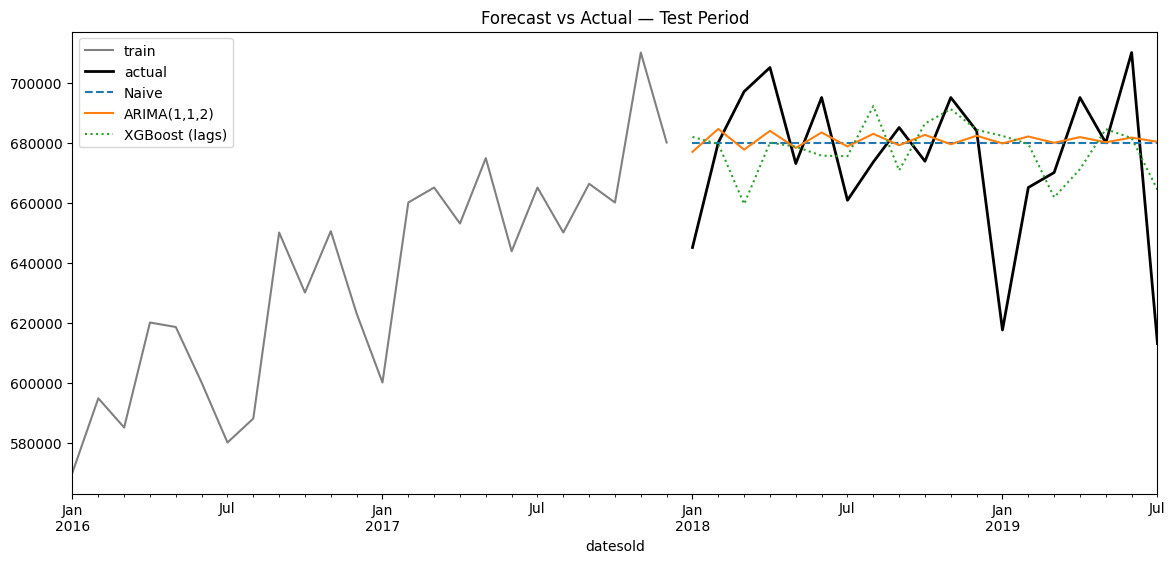

In [40]:
plt.rcParams["figure.figsize"] = (14, 6)
train.tail(24).plot(label="train", color="grey")
test.plot(label="actual", color="black", linewidth=2)
p_naive.plot(label="Naive", linestyle="--")
pd.Series(ARIMA(train, order=(1,1,2)).fit().forecast(len(test)).values,
          index=test.index).plot(label="ARIMA(1,1,2)")
p_xgb.plot(label="XGBoost (lags)", linestyle=":")
plt.title("Forecast vs Actual — Test Period")
plt.legend(); plt.show()

### Results

| Model | RMSE | MAE | MAPE |
|---|---|---|---|
| **ARIMA(2,1,2)** | **25,707** | 18,492 | **2.82%** |
| Naive | 26,133 | 18,658 | 2.85% |
| XGBoost (lags) | 26,400 | 20,266 | 3.07% |
| ARIMA(0,1,2) | 26,725 | 19,023 | 2.91% |
| SARIMA(0,1,1)(0,0,1,12) | 27,231 | 19,279 | 2.95% |
| Linear Regression (lags) | 30,537 | 23,535 | 3.59% |
| Seasonal Naive | 31,932 | 24,950 | 3.69% |
| Holt-Winters (damped) | 33,344 | 26,147 | 3.96% |
| SARIMAX + volume | 38,738 | 32,457 | 4.75% |
| Drift | 40,254 | 29,959 | 4.59% |
| Holt-Winters | 48,271 | 38,065 | 5.76% |
| SARIMA(0,1,1)(0,1,1,12) | 52,953 | 42,411 | 6.41% |

**ARIMA(2,1,2) beats the naive baseline by 1.6%** — a real but modest
improvement over predicting no change for nineteen months.

The ranking is explained almost entirely by **how much trend a model
extrapolates**. The series rose steadily from 2014 to 2017 and then
reversed during the test period. Models producing near-flat forecasts
occupy the top of the table; those projecting the prior trend forward
occupy the bottom. Undamped Holt-Winters (48,271) versus damped
(33,344) isolates this effect to a single parameter worth $15,000 of RMSE.

**Sales volume does not help.** SARIMAX scored 38,738 despite being given
*actual* future volume — information unavailable at forecast time. The
regressor fails even with an unfair advantage.

**The seasonal difference is actively harmful.** SARIMA(0,1,1)(0,1,1,12)
scored $52,953 against 27,231 for the identical model with D=0. The ADF
test in section 5 predicted this: adding a seasonal difference raised the
p-value from <0.0001 to 0.0056, indicating over-differencing.

R² is negative for every model because it compares against the mean of the
test period — a value no forecaster could know in advance, and a strong
benchmark across a nearly flat window. RMSE and MAPE are the meaningful
metrics here.

In [41]:
q = clean.set_index("datesold")["price"].resample("QE").median()["2009":]
q_train, q_test = q[:"2017"], q["2018":]
qm = ARIMA(q_train, order=(1,1,1)).fit()
qp = qm.forecast(len(q_test))
print("Quarterly RMSE:", round(np.sqrt(mean_squared_error(q_test, qp))))
print("Quarterly MAPE:", round((abs(q_test-qp)/q_test).mean()*100, 2), "%")

Quarterly RMSE: 27853
Quarterly MAPE: 2.77 %


### Does aggregation help?

Quarterly aggregation was tested on the hypothesis that month-to-month
variation reflects composition noise — which properties happen to
transact — rather than market movement. ARIMA(1,1,1) on quarterly medians
scored MAPE 2.77% against 2.82% monthly, but RMSE 27,853 against 25,707.

The improvement is marginal and inconsistent across metrics, so the
hypothesis is only weakly supported. Smoothing reduces relative error
slightly but does not make the level easier to forecast, which suggests
the limit is genuine unpredictability in the series rather than noise that
averaging can remove.

A quality-adjusted index — controlling for property size, location and
type rather than aggregating raw medians — would be the next thing to
test, and would isolate price movement from changes in the sales mix.

## 8. Conclusion

ARIMA(2,1,2) beats a naive no-change forecast by 1.6% (RMSE \25,707 vs
\$26,133) over a 19-month horizon. Fifteen specifications across four
model families were tested; eleven performed worse than predicting no
change at all.

The ranking is explained almost entirely by how much trend each model
extrapolates. The series rose from 2014 to 2017 and reversed during the
test period, so models producing near-flat forecasts occupy the top of the
table and trend-projecting models the bottom.

Three findings carry more weight than the winner:

1. **Over-differencing is costly.** SARIMA with D=1 scored \52,953
   against \27,231 for the identical model with D=0 — a single parameter
   doubling the error, predicted by the ADF test in section 5.
2. **Sales volume does not predict price**, even when the model is given
   actual future volume it could not know at forecast time.
3. **Lag-feature ML models solve an easier problem and still lose.**
   XGBoost forecasts one step ahead with fresh monthly data; ARIMA
   forecasts 19 months blind and beats it.

The practical ceiling is set by the target itself. Each monthly point is a
median over 100–300 sales, and which properties transact moves that median
independently of price. Quarterly aggregation was tested and only weakly
supported the hypothesis, suggesting genuine unpredictability rather than
removable noise.

In [42]:
import joblib, json
from statsmodels.tsa.arima.model import ARIMA

final = ARIMA(monthly["median_price"], order=(2,1,2)).fit()
final.save("arima_model.pkl")

metadata = {
    "model": "ARIMA(2,1,2)",
    "train_period": "2009-01 to 2017-12",
    "test_period": "2018-01 to 2019-07",
    "test_rmse": 25707,
    "test_mape": 2.82,
    "baseline_rmse": 26133,
    "improvement_pct": 1.6,
}
json.dump(metadata, open("forecast_metadata.json", "w"), indent=2)
print("saved")

saved
